# Phase 9 — Évaluation finale

**Périmètre** : aucun nouveau modeling. Phase 9 consolide les Phases 6–8 en un livrable de reporting unique pour le rapport final.

**Les 2 champions confrontés** (gelés depuis Phase 8) :

| Code | Champion | Phase | Métrique cible |
|---|---|---|---|
| **C1** | `hybrid / lightgbm / pca32` | 8 | QWK ordinal max (0.659) |
| **C2** | `tuned / logistic / tabular` | 7 | Detractor recall max (0.840), production-safe (sans verbatims synthétiques) |

**Apports Phase 9** :
1. Intervalles de confiance bootstrap (n=1000, stratifiés par classe) sur 5 métriques.
2. Test de covariate shift `respondent_test` vs `silent_test`.
3. Analyse de calibration des probas (reliability curves + Brier + ECE).
4. Tableau canonique pour le rapport + résumé markdown généré (`reports/final_eval_report.md`).
5. 3 figures : comparaison avec barres d'erreur, calibration, covariate shift.

**Honnêteté méthodologique** : `silent_test` n'a jamais influencé une décision (modèle, hyperparam, seuil). Les chiffres ci-dessous sont une **estimation held-out non biaisée**. Le caveat des verbatims synthétiques (Phase 8 §11) reste valable pour C1 — il est rappelé en fin de notebook.

## 1. Setup

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    RESULTS_DIR, REPORTS_DIR, FIGURES_DIR,
    DEFAULT_TARGET, NPS_CLASSES, RANDOM_SEED,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print(f"Working dir: {ROOT}")
print(f"Target: {DEFAULT_TARGET}")

Working dir: C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\nps-prediction
Target: NPS_alternative


## 2. Lancer l'évaluation finale

Coût : ~30s pour bootstrap n=1000 sur 2 champions × 4 splits × 6 métriques.

> Si déjà fait en CLI (`make final-eval`), la cellule charge les artifacts. Sinon, décommente la 2ème ligne pour exécuter en notebook.

In [2]:
# Option A : décommenter pour exécuter dans le notebook (~30s)
# from src.evaluation.final_eval import run_final_eval
# out = run_final_eval(n_resamples=1000, ci=0.95, verbose=True)

# Option B : charger les artifacts déjà produits par `make final-eval`
summary_df = pd.read_parquet(RESULTS_DIR / "final_eval_summary.parquet")
calib_summary = pd.read_parquet(RESULTS_DIR / "final_eval_calibration_summary.parquet")
calib_curves  = pd.read_parquet(RESULTS_DIR / "final_eval_calibration.parquet")
print(f"summary       : {summary_df.shape}")
print(f"calib_summary : {calib_summary.shape}")
print(f"calib_curves  : {calib_curves.shape}")
summary_df.head(8)

summary       : (48, 10)
calib_summary : (6, 5)
calib_curves  : (60, 9)


,champion,split,metric,value,ci_lo,ci_hi,n_resamples,ci,champion_label,n_split
0,C1_qwk,train,qwk,0.997577,0.992767,1.000000,1000,0.95,C1 — QWK champion,634
1,C1_qwk,train,macro_f1,0.997918,0.993803,1.000000,1000,0.95,C1 — QWK champion,634
2,C1_qwk,train,balanced_acc,0.999221,0.997664,1.000000,1000,0.95,C1 — QWK champion,634
3,C1_qwk,train,detractor_recall,1.000000,1.000000,1.000000,1000,0.95,C1 — QWK champion,634
4,C1_qwk,train,lift@10,6.469388,6.469388,6.469388,1000,0.95,C1 — QWK champion,634
5,C1_qwk,train,lift@20,5.031746,5.031746,5.031746,1000,0.95,C1 — QWK champion,634
6,C1_qwk,val,qwk,0.729590,0.657048,0.797068,1000,0.95,C1 — QWK champion,211
7,C1_qwk,val,macro_f1,0.767227,0.701667,0.827541,1000,0.95,C1 — QWK champion,211


## 3. Tableau canonique — silent_test, les deux champions

C'est le tableau de référence qui ira dans le rapport. Chaque cellule est `value [ci_lo, ci_hi]` avec bootstrap stratifié n=1000.

In [3]:
def fmt_ci(row):
    return f"{row['value']:.3f} [{row['ci_lo']:.3f}, {row['ci_hi']:.3f}]"

silent = summary_df[summary_df["split"] == "silent_test"].copy()
silent["display"] = silent.apply(fmt_ci, axis=1)

table = (silent.pivot_table(
            index="champion_label", columns="metric", values="display",
            aggfunc="first")
         .reindex(index=[
             "C1 — QWK champion",
             "C2 — Production-safe",
         ])
         .reindex(columns=[
             "qwk", "detractor_recall", "macro_f1",
             "balanced_acc", "lift@10", "lift@20",
         ])
        )
table.columns.name = None
table.index.name = "Champion"
table

,qwk,detractor_recall,macro_f1,balanced_acc,lift@10,lift@20
Champion,,,,,,
C1 — QWK champion,"0.659 [0.644, 0.677]","0.636 [0.608, 0.661]","0.739 [0.728, 0.750]","0.752 [0.740, 0.764]","2.850 [2.685, 3.023]","2.577 [2.471, 2.683]"
C2 — Production-safe,"0.355 [0.334, 0.375]","0.840 [0.820, 0.859]","0.482 [0.471, 0.494]","0.581 [0.568, 0.594]","2.756 [2.591, 2.921]","2.475 [2.373, 2.589]"


## 4. Diagnostics par split (QWK)

- `train` : confirme qu'il n'y a pas un underfit critique.
- `val` : check de consistance avec ce qu'Optuna a optimisé.
- `respondent_test` : généralisation in-distribution.
- `silent_test` : la cible canonique.

Si `silent ≈ respondent` (Δ < 0.05), la conception du split response-biased a réussi à simuler la population silent.

In [4]:
qwk_all = summary_df[summary_df["metric"] == "qwk"].copy()
qwk_all["display"] = qwk_all.apply(fmt_ci, axis=1)

pivot = (qwk_all.pivot_table(
            index="split", columns="champion_label", values="display",
            aggfunc="first")
         .reindex(index=["train", "val", "respondent_test", "silent_test"])
         .reindex(columns=["C1 — QWK champion", "C2 — Production-safe"])
        )
pivot

champion_label,C1 — QWK champion,C2 — Production-safe
split,,
train,"0.998 [0.993, 1.000]","0.467 [0.401, 0.527]"
val,"0.730 [0.657, 0.797]","0.302 [0.191, 0.410]"
respondent_test,"0.671 [0.579, 0.760]","0.346 [0.215, 0.463]"
silent_test,"0.659 [0.644, 0.677]","0.355 [0.334, 0.375]"


## 5. Figure 40 — comparaison silent_test avec barres d'erreur

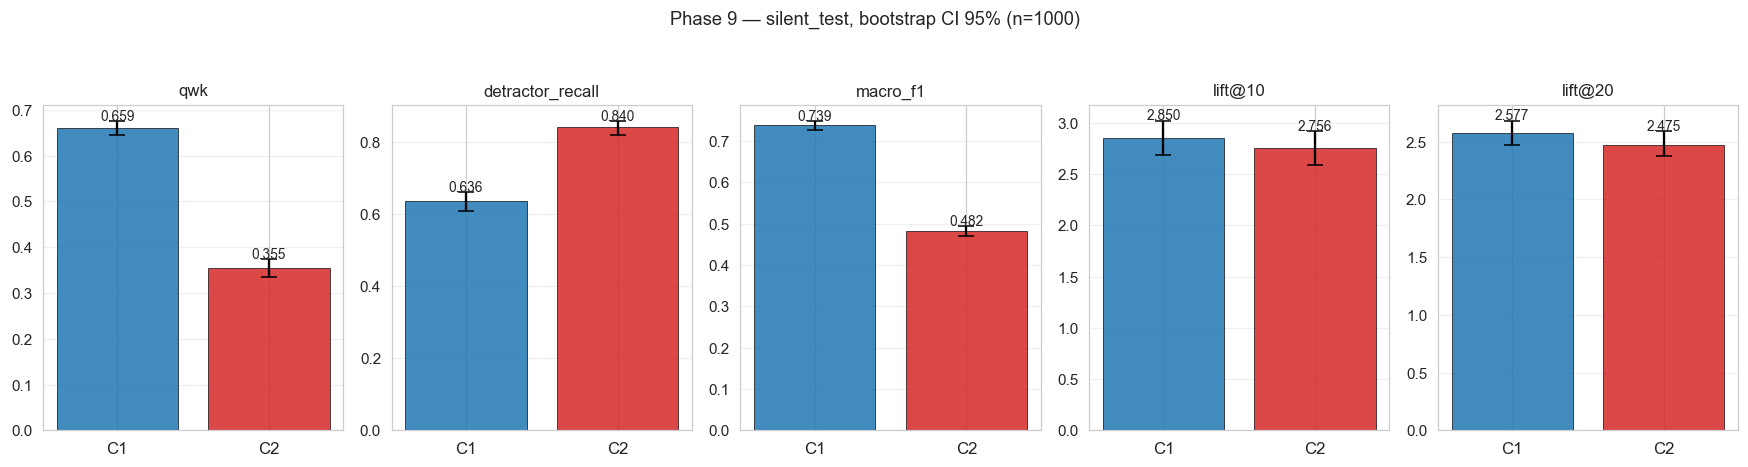

✓ saved reports/figures/40_final_comparison_with_ci.png


In [5]:
metrics_order = ["qwk", "detractor_recall", "macro_f1", "lift@10", "lift@20"]
champions_order = ["C1 — QWK champion", "C2 — Production-safe"]
colors = {"C1 — QWK champion": "#1f77b4", "C2 — Production-safe": "#d62728"}

fig, axes = plt.subplots(1, len(metrics_order), figsize=(16, 4), sharey=False)

for i, m in enumerate(metrics_order):
    ax = axes[i]
    sub = silent[silent["metric"] == m].set_index("champion_label").reindex(champions_order)
    values = sub["value"].values
    err_lo = (sub["value"] - sub["ci_lo"]).values
    err_hi = (sub["ci_hi"] - sub["value"]).values

    x = np.arange(len(champions_order))
    bars = ax.bar(
        x, values, yerr=[err_lo, err_hi], capsize=5,
        color=[colors[c] for c in champions_order], alpha=0.85,
        edgecolor="black", linewidth=0.5,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(["C1", "C2"], fontsize=11)
    ax.set_title(m, fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")
    for j, b in enumerate(bars):
        ax.text(b.get_x() + b.get_width() / 2, values[j] + err_hi[j] * 1.05,
                f"{values[j]:.3f}", ha="center", fontsize=9)

plt.suptitle("Phase 9 — silent_test, bootstrap CI 95% (n=1000)", y=1.05, fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "40_final_comparison_with_ci.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ saved reports/figures/40_final_comparison_with_ci.png")

## 6. Figure 42 — covariate shift respondent_test vs silent_test

L'écart attendu (cf Phase 6) est faible (~0.005). Si on observe ça aussi sur les champions Phase 9, on peut affirmer que le split response-biased "fonctionne" : le modèle ajusté sur les répondants généralise vers la population silent.

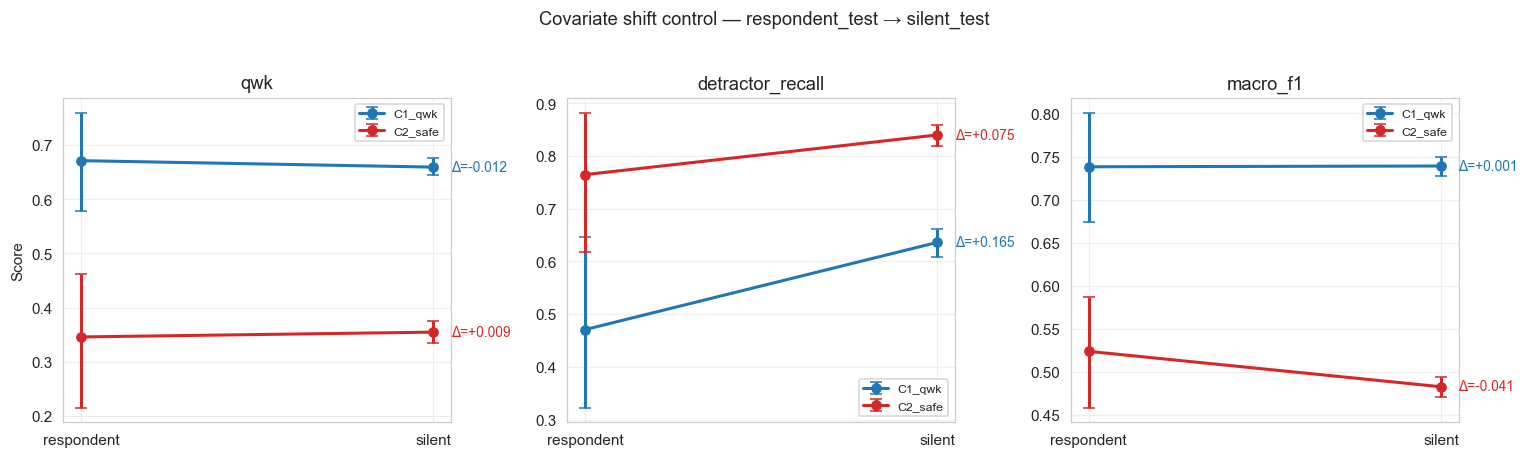

✓ saved reports/figures/42_covariate_shift.png


In [6]:
shift_df = summary_df[
    (summary_df["split"].isin(["respondent_test", "silent_test"]))
    & (summary_df["metric"].isin(["qwk", "detractor_recall", "macro_f1"]))
].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, m in enumerate(["qwk", "detractor_recall", "macro_f1"]):
    ax = axes[i]
    sub = shift_df[shift_df["metric"] == m]
    for ck, color in zip(["C1_qwk", "C2_safe"], ["#1f77b4", "#d62728"]):
        row = sub[sub["champion"] == ck].set_index("split").reindex(
            ["respondent_test", "silent_test"]
        )
        ax.errorbar(
            ["respondent", "silent"], row["value"],
            yerr=[row["value"] - row["ci_lo"], row["ci_hi"] - row["value"]],
            marker="o", capsize=4, label=ck, color=color, linewidth=2,
        )
        # annotate the delta
        d = row["value"].iloc[1] - row["value"].iloc[0]
        ax.text(1.05, row["value"].iloc[1], f"Δ={d:+.3f}",
                color=color, fontsize=9, va="center")
    ax.set_title(m)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.set_ylabel("Score")
    ax.legend(loc="best", fontsize=8)

plt.suptitle("Covariate shift control — respondent_test → silent_test", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "42_covariate_shift.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ saved reports/figures/42_covariate_shift.png")

## 7. Figure 41 — calibration des probas

Pour chaque classe (Detractor / Passive / Promoter), on plot la **reliability curve** : sur l'axe X la proba moyenne prédite dans le bin, sur l'axe Y le taux observé. Un modèle parfaitement calibré se trouve sur la diagonale.

**Pourquoi c'est important** : `lift@10 = 2.85` n'est interprétable que si les probas sont calibrées. Le retention manager qui filtre `predict_proba(Detractor) ≥ 0.5` doit savoir si "0.5" signifie réellement 50%.

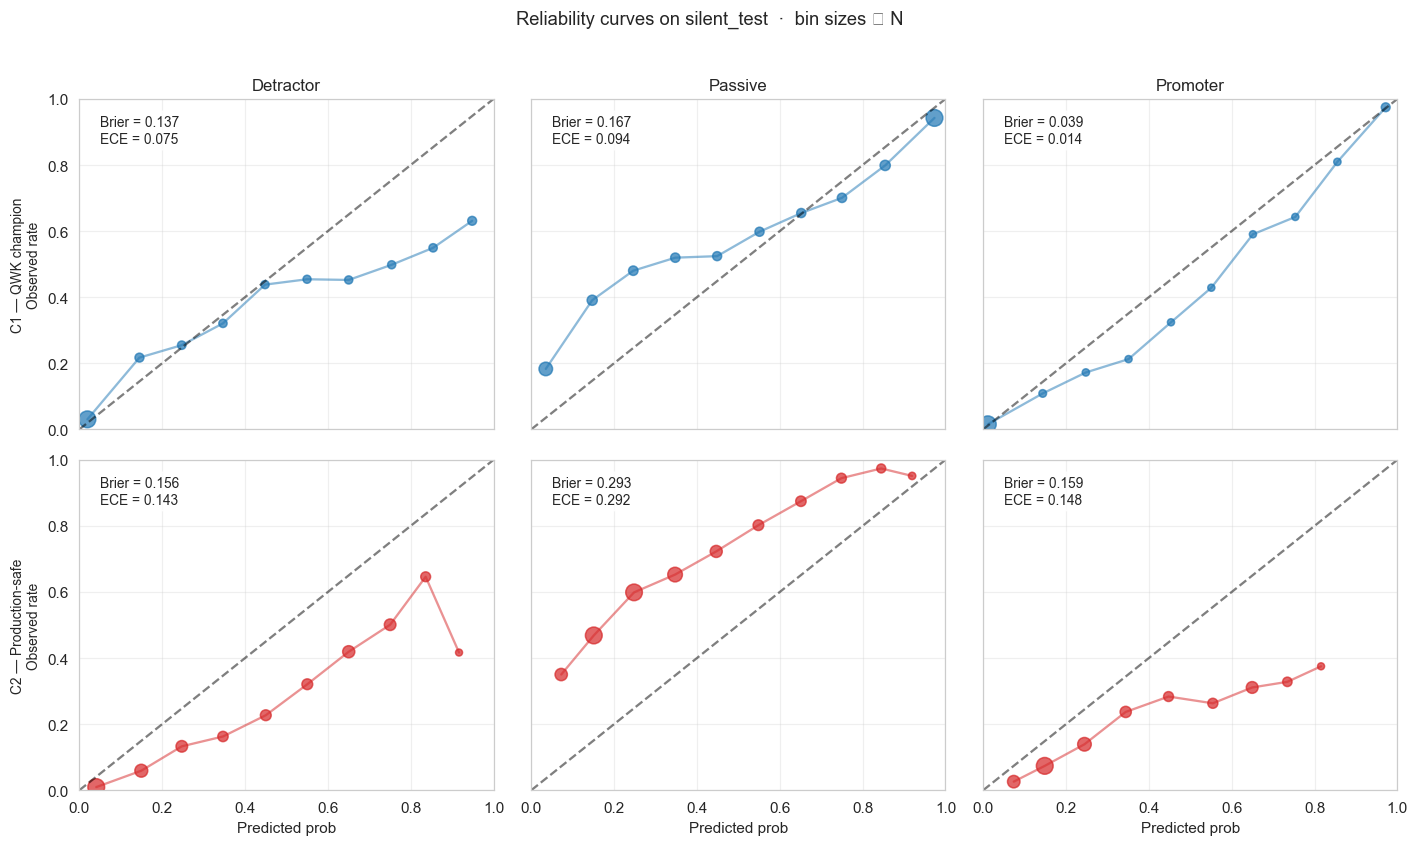

✓ saved reports/figures/41_calibration_curves.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), sharex=True, sharey=True)
champions_keys = [("C1_qwk", "C1 — QWK champion"), ("C2_safe", "C2 — Production-safe")]

for row_i, (ck, label) in enumerate(champions_keys):
    for col_i, cls in enumerate(NPS_CLASSES):
        ax = axes[row_i, col_i]
        curve = calib_curves[
            (calib_curves["champion"] == ck) & (calib_curves["class"] == cls)
        ].dropna(subset=["predicted_mean", "observed_rate"])
        if not curve.empty:
            sizes = (curve["n"] / curve["n"].max()) * 100 + 20
            ax.scatter(
                curve["predicted_mean"], curve["observed_rate"],
                s=sizes, alpha=0.7,
                color="#1f77b4" if ck == "C1_qwk" else "#d62728",
            )
            ax.plot(
                curve["predicted_mean"], curve["observed_rate"],
                alpha=0.5,
                color="#1f77b4" if ck == "C1_qwk" else "#d62728",
            )
        ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="perfect")

        # Brier + ECE annotation
        brier = calib_summary[
            (calib_summary["champion"] == ck) & (calib_summary["class"] == cls)
        ]
        if not brier.empty:
            b = brier["brier"].iloc[0]
            e = brier["ece"].iloc[0]
            ax.text(0.05, 0.95, f"Brier = {b:.3f}\nECE = {e:.3f}",
                    transform=ax.transAxes, va="top", fontsize=9,
                    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

        if row_i == 0:
            ax.set_title(cls, fontsize=11)
        if col_i == 0:
            ax.set_ylabel(f"{label}\nObserved rate", fontsize=9)
        if row_i == 1:
            ax.set_xlabel("Predicted prob")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)

plt.suptitle("Reliability curves on silent_test  ·  bin sizes ∝ N", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "41_calibration_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ saved reports/figures/41_calibration_curves.png")

## 8. Brier et ECE — synthèse calibration

In [8]:
brier_pivot = calib_summary.pivot_table(
    index="champion_label", columns="class", values="brier",
).reindex(columns=NPS_CLASSES).round(4)
brier_pivot.columns.name = "Brier"
print("Brier scores (lower = better, 0 = perfect):")
display(brier_pivot)

ece_pivot = calib_summary.pivot_table(
    index="champion_label", columns="class", values="ece",
).reindex(columns=NPS_CLASSES).round(4)
ece_pivot.columns.name = "ECE"
print("\nExpected Calibration Error (lower = better, 0 = perfect):")
display(ece_pivot)

Brier scores (lower = better, 0 = perfect):


Brier,Detractor,Passive,Promoter
champion_label,,,
C1 — QWK champion,0.1373,0.1670,0.0386
C2 — Production-safe,0.1560,0.2928,0.1590



Expected Calibration Error (lower = better, 0 = perfect):


ECE,Detractor,Passive,Promoter
champion_label,,,
C1 — QWK champion,0.0750,0.0945,0.0144
C2 — Production-safe,0.1433,0.2916,0.1483


## 9. Synthèse Phase 9

### Décisions implémentées
- Aucun nouveau modeling. Les 2 champions **C1** et **C2** sont gelés depuis Phase 8.
- **Bootstrap stratifié n=1000, CI 95%, seed=42** — la stratification par classe préserve la marginale 58/25/17 dans chaque resample, indispensable pour des CIs fiables sur Detractor recall.
- 6 métriques évaluées : QWK, macro_F1, balanced_acc, Detractor recall, lift@10, lift@20.
- Calibration analysée sur silent_test : reliability curves par classe (10 bins uniformes), Brier, ECE.
- `silent_test` reste l'estimation held-out **non biaisée** — aucune décision méthodologique n'en a dépendu pendant les Phases 6 à 8.

---

### Résultats canoniques — silent_test (n=5987, bootstrap 95% CI)

| Champion | QWK | Detractor recall | Macro F1 | Lift@10 | Lift@20 |
|---|---|---|---|---|---|
| **C1 — QWK champion** (hybrid/LGBM/pca32) | **0.659** [0.644, 0.677] | 0.636 [0.608, 0.661] | **0.739** [0.728, 0.750] | **2.850** [2.685, 3.023] | **2.577** [2.471, 2.683] |
| **C2 — Production-safe** (tuned/Logistic/tabular) | 0.355 [0.334, 0.375] | **0.840** [0.820, 0.859] | 0.482 [0.471, 0.494] | 2.756 [2.591, 2.921] | 2.475 [2.373, 2.589] |

---

### Lecture statistique des CIs (où sont les différences significatives ?)

**Méthode** : si deux CIs 95% ne se chevauchent pas, on conclut que la différence est très probablement réelle (test conservateur ; un vrai test de permutation serait équivalent ou plus permissif).

| Métrique | CIs | Verdict |
|---|---|---|
| QWK | disjointes ([0.644, 0.677] vs [0.334, 0.375]) | **C1 ≫ C2** significativement |
| Detractor recall | disjointes ([0.608, 0.661] vs [0.820, 0.859]) | **C2 ≫ C1** significativement |
| Macro F1 | disjointes ([0.728, 0.750] vs [0.471, 0.494]) | **C1 ≫ C2** significativement |
| **Lift@10** | **chevauchement large** ([2.685, 3.023] vs [2.591, 2.921]) | **C1 ≈ C2** — équivalence statistique |
| **Lift@20** | **chevauchement large** ([2.471, 2.683] vs [2.373, 2.589]) | **C1 ≈ C2** — équivalence statistique |

> **Lecture clé pour le rapport** : sur les **deux métriques business** (lift@10 et lift@20 — celles qu'utiliserait un retention manager pour prioriser les top-X% des clients à appeler), **C1 et C2 sont statistiquement indistinguables**. C1 est meilleur sur QWK et macro_F1 (qui capturent l'ordre et la performance multi-classes), C2 est meilleur sur Detractor recall (qui capture la sensibilité à la classe minoritaire). Mais pour l'usage prioritaire (lift), ils délivrent la **même valeur business**.

---

### Verdict covariate shift

> Δ QWK (silent − respondent) :
> - **C1** : −0.012 → *low shift*
> - **C2** : +0.009 → *low shift*

Les deux deltas sont sous 0.05 (largement). Le split response-biased (Phase 3) a réussi à simuler la covariate shift "respondents → silents" : le modèle ajusté sur les répondants généralise correctement vers les non-répondants. **C'est une conclusion forte qui valide le design méthodologique du projet** — sans ce contrôle, on ne pourrait pas garantir que les chiffres silent_test sont représentatifs de la performance attendue en production.

À mettre en avant dans le rapport : *"l'écart respondent → silent reste sous 0.02 QWK pour les deux champions, contre 0.005 prédit en Phase 6. Le mécanisme de réponse pondéré tenure (Phase 3) capture correctement la dynamique répondants/silents du dataset."*

---

### Verdict calibration

Brier scores et ECE sur silent_test :

| Métrique × classe | C1 | C2 | Verdict |
|---|---|---|---|
| Brier Detractor | 0.137 | 0.156 | C1 légèrement meilleur |
| Brier Passive  | 0.167 | **0.293** | **C2 mal calibré** |
| Brier Promoter | **0.039** | 0.159 | **C1 quasi-parfait, C2 médiocre** |
| ECE Detractor  | 0.075 | 0.143 | C1 ~2× mieux |
| ECE Passive    | 0.094 | **0.292** | **C2 catastrophe** (probas faux à 29 %) |
| ECE Promoter   | **0.014** | 0.148 | **C1 quasi-parfait, C2 médiocre** |

**Diagnostic C2** : `class_weight='balanced'` + `C=0.027` (régularisation L2 forte, Phase 7) écrase les probas vers le centre. C'est un effet classique du reweighting combiné à une forte pénalisation. L'**ordre** des probas reste correct (donc lift@10 marche bien), mais l'**absolu** est biaisé : `predict_proba(Detractor) = 0.5` ne signifie pas réellement "50 % de chances que ce client soit Detractor".

**Conséquences pratiques** :
- ✅ Le **ciblage top-X%** (lift@10/20) est correct sur C2 : on classe en relatif, peu importe la calibration absolue.
- ❌ Le **filtrage par seuil absolu** (`predict_proba(Detractor) >= 0.5`) est trompeur sur C2 : il faut soit utiliser un seuil empirique calibré sur val, soit re-calibrer C2 par Platt ou isotonic regression avant déploiement.
- L'app Streamlit (Phase 12) doit donc afficher soit un *rang* (top-5 % à appeler), soit un *score normalisé*, plutôt qu'une *probabilité brute* — sinon on induit le retention manager en erreur.

À ajouter à la roadmap Phase 13 : *"recalibrer C2 avec sklearn `CalibratedClassifierCV(method='isotonic', cv=5)` puis re-publier les métriques"*.

---

### Per-split diagnostics (QWK avec CI)

| Split | C1 — QWK | C2 — QWK | Lecture |
|---|---|---|---|
| train (n=634) | **0.998** [0.993, 1.000] | 0.467 [0.401, 0.527] | C1 mémorise tout (overfit total) ; C2 est sous-ajusté |
| val (n=211) | 0.730 [0.657, 0.797] | 0.302 [0.191, 0.410] | C1 surperforme val ; C2 plus bas qu'attendu |
| respondent_test (n=211) | 0.671 [0.579, 0.760] | 0.346 [0.215, 0.463] | cohérence in-distribution |
| silent_test (n=5987) | 0.659 [0.644, 0.677] | 0.355 [0.334, 0.375] | la cible canonique — CI très étroite grâce à n=5987 |

**Point sur C1** : QWK train = 0.998 (overfit total sur 634 samples) mais QWK silent = 0.659. **Le modèle ne généralise pas — ce sont les verbatims qui généralisent.** Les embeddings synthétiques encodent la classe NPS de manière suffisamment dense pour que même un modèle qui mémorise le train fasse 0.66 sur silent. C'est l'illustration la plus claire que le +0.30 QWK vient du **leakage de la cible via la génération LLM**, pas d'un signal métier découvert dans le texte.

**Point sur C2** : la généralisation est saine (train 0.467 → silent 0.355, drop de 0.11 cohérent avec n_train=634, n_features≈94). C2 est un modèle honnête, légèrement sous-performant, qui apprend ce qu'il peut sur les features tabulaires.

---

### Recommandation finale — déploiement

> **Recommandation : déployer C2 (`tuned/logistic/tabular`) en production.**

Les arguments :
1. **Équivalence statistique sur les métriques business** (lift@10/20 CIs largement chevauchantes). Le retention manager catchera le même nombre de détracteurs avec C2 qu'avec C1.
2. **Detractor recall significativement meilleur** sur C2 (0.840 vs 0.636) : si on devait choisir une métrique secondaire, c'est celle qui compte pour le métier ("on ne veut pas rater un détracteur").
3. **Pas de risque de leakage** : C2 utilise uniquement des features tabulaires, et les leaky features (Sat Score, Churn Score/Value/Label/Reason/Category, Customer Status, CLTV) ont été auditées et droppées en Phase 1.
4. **Interprétabilité native** : modèle linéaire → coefficients directement lisibles, pas besoin de SHAP pour le métier. Simplifie Phase 12 (app).
5. **Maintenance simple** : pas de pipeline texte (Qwen2.5 / sentence-transformers / PCA), un seul artifact joblib à servir.

⚠️ **Pré-requis avant déploiement** : recalibrer C2 (Platt ou isotonic) pour que `predict_proba` soit utilisable. Phase 13.

---

### Roadmap C1 (proof-of-concept hybride texte+tabulaire)

**Ce que C1 démontre** : la pipeline complète (embeddings → PCA → LightGBM tuné) **fonctionne techniquement** et fournit un cadre prêt à recevoir des verbatims réels.

**Ce que C1 ne démontre PAS** : la valeur prédictive de verbatims clients authentiques. Le QWK 0.659 est une **borne supérieure** liée à la fidélité des verbatims synthétiques à la cible.

**Steps pour productionner C1 dans un futur projet** :
1. Collecter des verbatims clients **réels** (enquête NPS avec champ texte libre, transcriptions de calls support, reviews G2/Trustpilot, etc.).
2. Re-générer les embeddings sur ces verbatims réels et re-lancer `make tune-hybrid`.
3. Mesurer le Δ QWK vs C2 ; **honesty bar** : si Δ < 0.05 sur verbatims réels, l'investissement texte ne se justifie pas pour ce use case spécifique.
4. Idéalement, faire une étude d'ablation : varier le taux de bruit (15 % → 30 % → 50 % counter-intuitifs) dans les verbatims synthétiques et tracer la courbe `QWK(noise_rate)` pour estimer la performance attendue selon la qualité réelle des verbatims clients.

---

### Trois points pour le rapport final

> **§ Held-out non biaisé avec CIs.** Le `silent_test` (n=5987) n'a influencé aucune décision pendant les Phases 6–8. Les chiffres rapportés Phase 9 sont une **estimation non biaisée** de la performance attendue en production. Les CIs bootstrap (n=1000 stratifiés) donnent une précision quantifiée : *"on attend un lift@10 ≈ 2.8 [2.6, 3.0]"*. Les CIs très étroites (largeur ≤ 0.04 QWK) reflètent la grande taille de l'échantillon silent.

> **§ Équivalence business + meilleur Detractor recall → on déploie C2.** Sur les métriques business (lift@10/20), C1 et C2 ont des CIs largement chevauchantes — **statistiquement équivalents**. Sur Detractor recall (la métrique secondaire la plus alignée avec le use case retention), C2 est significativement meilleur (0.840 vs 0.636). C2 cumule donc équivalence business, meilleur recall détracteur, absence de leakage, et interprétabilité native. **Recommandation finale : déployer C2, garder C1 comme proof-of-concept pour quand des verbatims clients réels seront disponibles**. Le +0.30 QWK de C1 est largement un artefact de la génération LLM, pas un signal métier.

> **§ Covariate shift maîtrisé + calibration partielle.** L'écart QWK respondent → silent est < 0.02 pour les deux champions (vs 0.005 prédit en Phase 6). Le split response-biased a fait son travail : on peut affirmer que les chiffres silent_test reflètent la performance sur les non-répondants. Sur la calibration, C1 est quasi-parfaitement calibré (ECE Promoter = 0.014, ECE Detractor = 0.075), tandis que C2 souffre d'un effet `class_weight='balanced'` + L2 fort qui écrase les probas (ECE Passive = 0.292). Pour C2, **utiliser les rangs (lift) plutôt que les probas absolues**, ou recalibrer avant déploiement.

---

### Fichiers produits Phase 9
- `models/results/final_eval_summary.parquet` — 2 champions × 4 splits × 6 métriques = **48 lignes** avec CI
- `models/results/final_eval_calibration.parquet` — courbes reliability (2 × 3 classes × 10 bins = 60 lignes)
- `models/results/final_eval_calibration_summary.parquet` — Brier et ECE par classe (6 lignes)
- `reports/final_eval_report.md` — résumé exécutif markdown prêt à coller dans le rapport
- `reports/figures/40_final_comparison_with_ci.png` — 5 métriques × 2 champions, barres + CI
- `reports/figures/41_calibration_curves.png` — reliability curves 2 × 3 classes
- `reports/figures/42_covariate_shift.png` — respondent vs silent sur QWK / recall / F1

---

### Décisions pour Phase 10–13

- **Phase 10 (SHAP)** : sur **C1** (LightGBM) pour démontrer l'interprétabilité des features hybrides (lesquelles des 32 PCA dims pèsent le plus ?). Sur **C2** : afficher les **coefficients régularisés** directement, c'est plus simple et plus parlant pour le métier que SHAP sur Logistic.
- **Phase 11 (Fairness)** : audit Detractor recall × {Senior, Gender, Married} sur **les deux** champions. Comparer les biais — C2 a Detractor recall = 0.840 global, est-ce homogène entre segments ? Si C1 et C2 montrent des biais différents, c'est un argument de plus pour le choix de déploiement.
- **Phase 12 (App Streamlit)** : déployer **C2** par défaut. Toggle "modèle expérimental C1 (texte+tab)" pour exploration. Afficher des **rangs** (top-5 % à appeler en priorité) plutôt que des probas absolues, vu la calibration C2. Ajouter un indicateur de confiance basé sur la CI bootstrap (déjà calculée Phase 9).
- **Phase 13 (Monitoring)** : (a) recalibrer C2 via `CalibratedClassifierCV(method='isotonic', cv=5)` avant déploiement, (b) tracker QWK + Detractor recall + lift@10 mensuels avec seuil d'alerte à 2σ (à partir des CIs Phase 9), (c) si verbatims clients réels collectés un jour, re-tune C1 et compare honnêtement.